# Notebook 88 — Hough internal knob audit on representative worst frames

This notebook keeps the same per-frame binary fascicle mask fixed and changes only Hough-side internals: diagonal replacement, radius correction, and peak extraction from 2D `houghpeaks` vs 1D angle-profile maxima.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_hough_knob_audit.py'
OUT = ROOT / 'results' / 'notebook88_hough_knob_audit'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_hough_knob_audit.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook88_hough_knob_audit


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

Auditing Hough knobs on aligned frame 71 (python frame 72)
Auditing Hough knobs on aligned frame 910 (python frame 911)
Auditing Hough knobs on aligned frame 1171 (python frame 1172)
Auditing Hough knobs on aligned frame 882 (python frame 883)
Auditing Hough knobs on aligned frame 2553 (python frame 2554)
Auditing Hough knobs on aligned frame 118 (python frame 119)
Auditing Hough knobs on aligned frame 730 (python frame 731)
Auditing Hough knobs on aligned frame 980 (python frame 981)
Auditing Hough knobs on aligned frame 1141 (python frame 1142)
Auditing Hough knobs on aligned frame 1414 (python frame 1415)
Auditing Hough knobs on aligned frame 96 (python frame 97)
Auditing Hough knobs on aligned frame 437 (python frame 438)
Auditing Hough knobs on aligned frame 613 (python frame 614)
Auditing Hough knobs on aligned frame 1234 (python frame 1235)
Auditing Hough knobs on aligned frame 2215 (python frame 2216)
Auditing Hough knobs on aligned frame 2520 (python frame 2521)
# Notebook 88 

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_hough_knob_audit.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook88_summary.md').read_text()))

# Notebook 88 — Hough internal knob audit on representative worst frames

Audited 16 representative worst frames from notebook 87 while keeping the same per-frame binary fascicle mask fixed and changing only Hough-side internals.

This notebook isolates four suspect areas inside the raw Hough path:

1. 45 deg diagonal-bias replacement;
2. ellipse/radius correction;
3. 2D `houghpeaks` suppression versus 1D angle-profile peak extraction;
4. angle-bin / gamma-grid alignment diagnostics.

## Key findings

- The best raw-alpha RMSE on these worst frames is `angle_profile_localmax_no_radius` at 6.2124 deg, versus 13.0450 deg for the current baseline.
- The baseline mean cumulative weight at MATLAB alpha is 0.1988. The best variant reaches 0.8166.
- Baseline higher-angle-overweight rate is 0.8125; the best variant changes it to 0.0000.
- MATLAB alpha is already aligned to the Python gamma grid very closely (mean nearest-grid distance 0.0000 deg, max 0.0000 deg), so angle-bin / gamma-grid mismatch does not look like the dominant issue on these frames.

## Interpretation

- If disabling radius correction helps most, the higher-angle bias is being introduced mainly by the correction weighting rather than by peak extraction.
- If switching from 2D `houghpeaks` to 1D profile peaks helps most, the problem is duplicate/suppressed peak structure across rho rather than the accumulator itself.
- If diagonal replacement matters, the 45 deg workaround is leaking weight into the wrong family.
- If none of these materially improves raw parity, the remaining problem is earlier still: the mask and underlying accumulator population before any of these knobs act.

- Per-frame metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook88_hough_knob_audit/hough_knob_frame_metrics.csv`
- Variant summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook88_hough_knob_audit/hough_knob_variant_summary.csv`
- Bias mode CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook88_hough_knob_audit/hough_knob_bias_mode_counts.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook88_hough_knob_audit/hough_knob_summary.png`
- Exemplar plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook88_hough_knob_audit/hough_knob_exemplars.png`


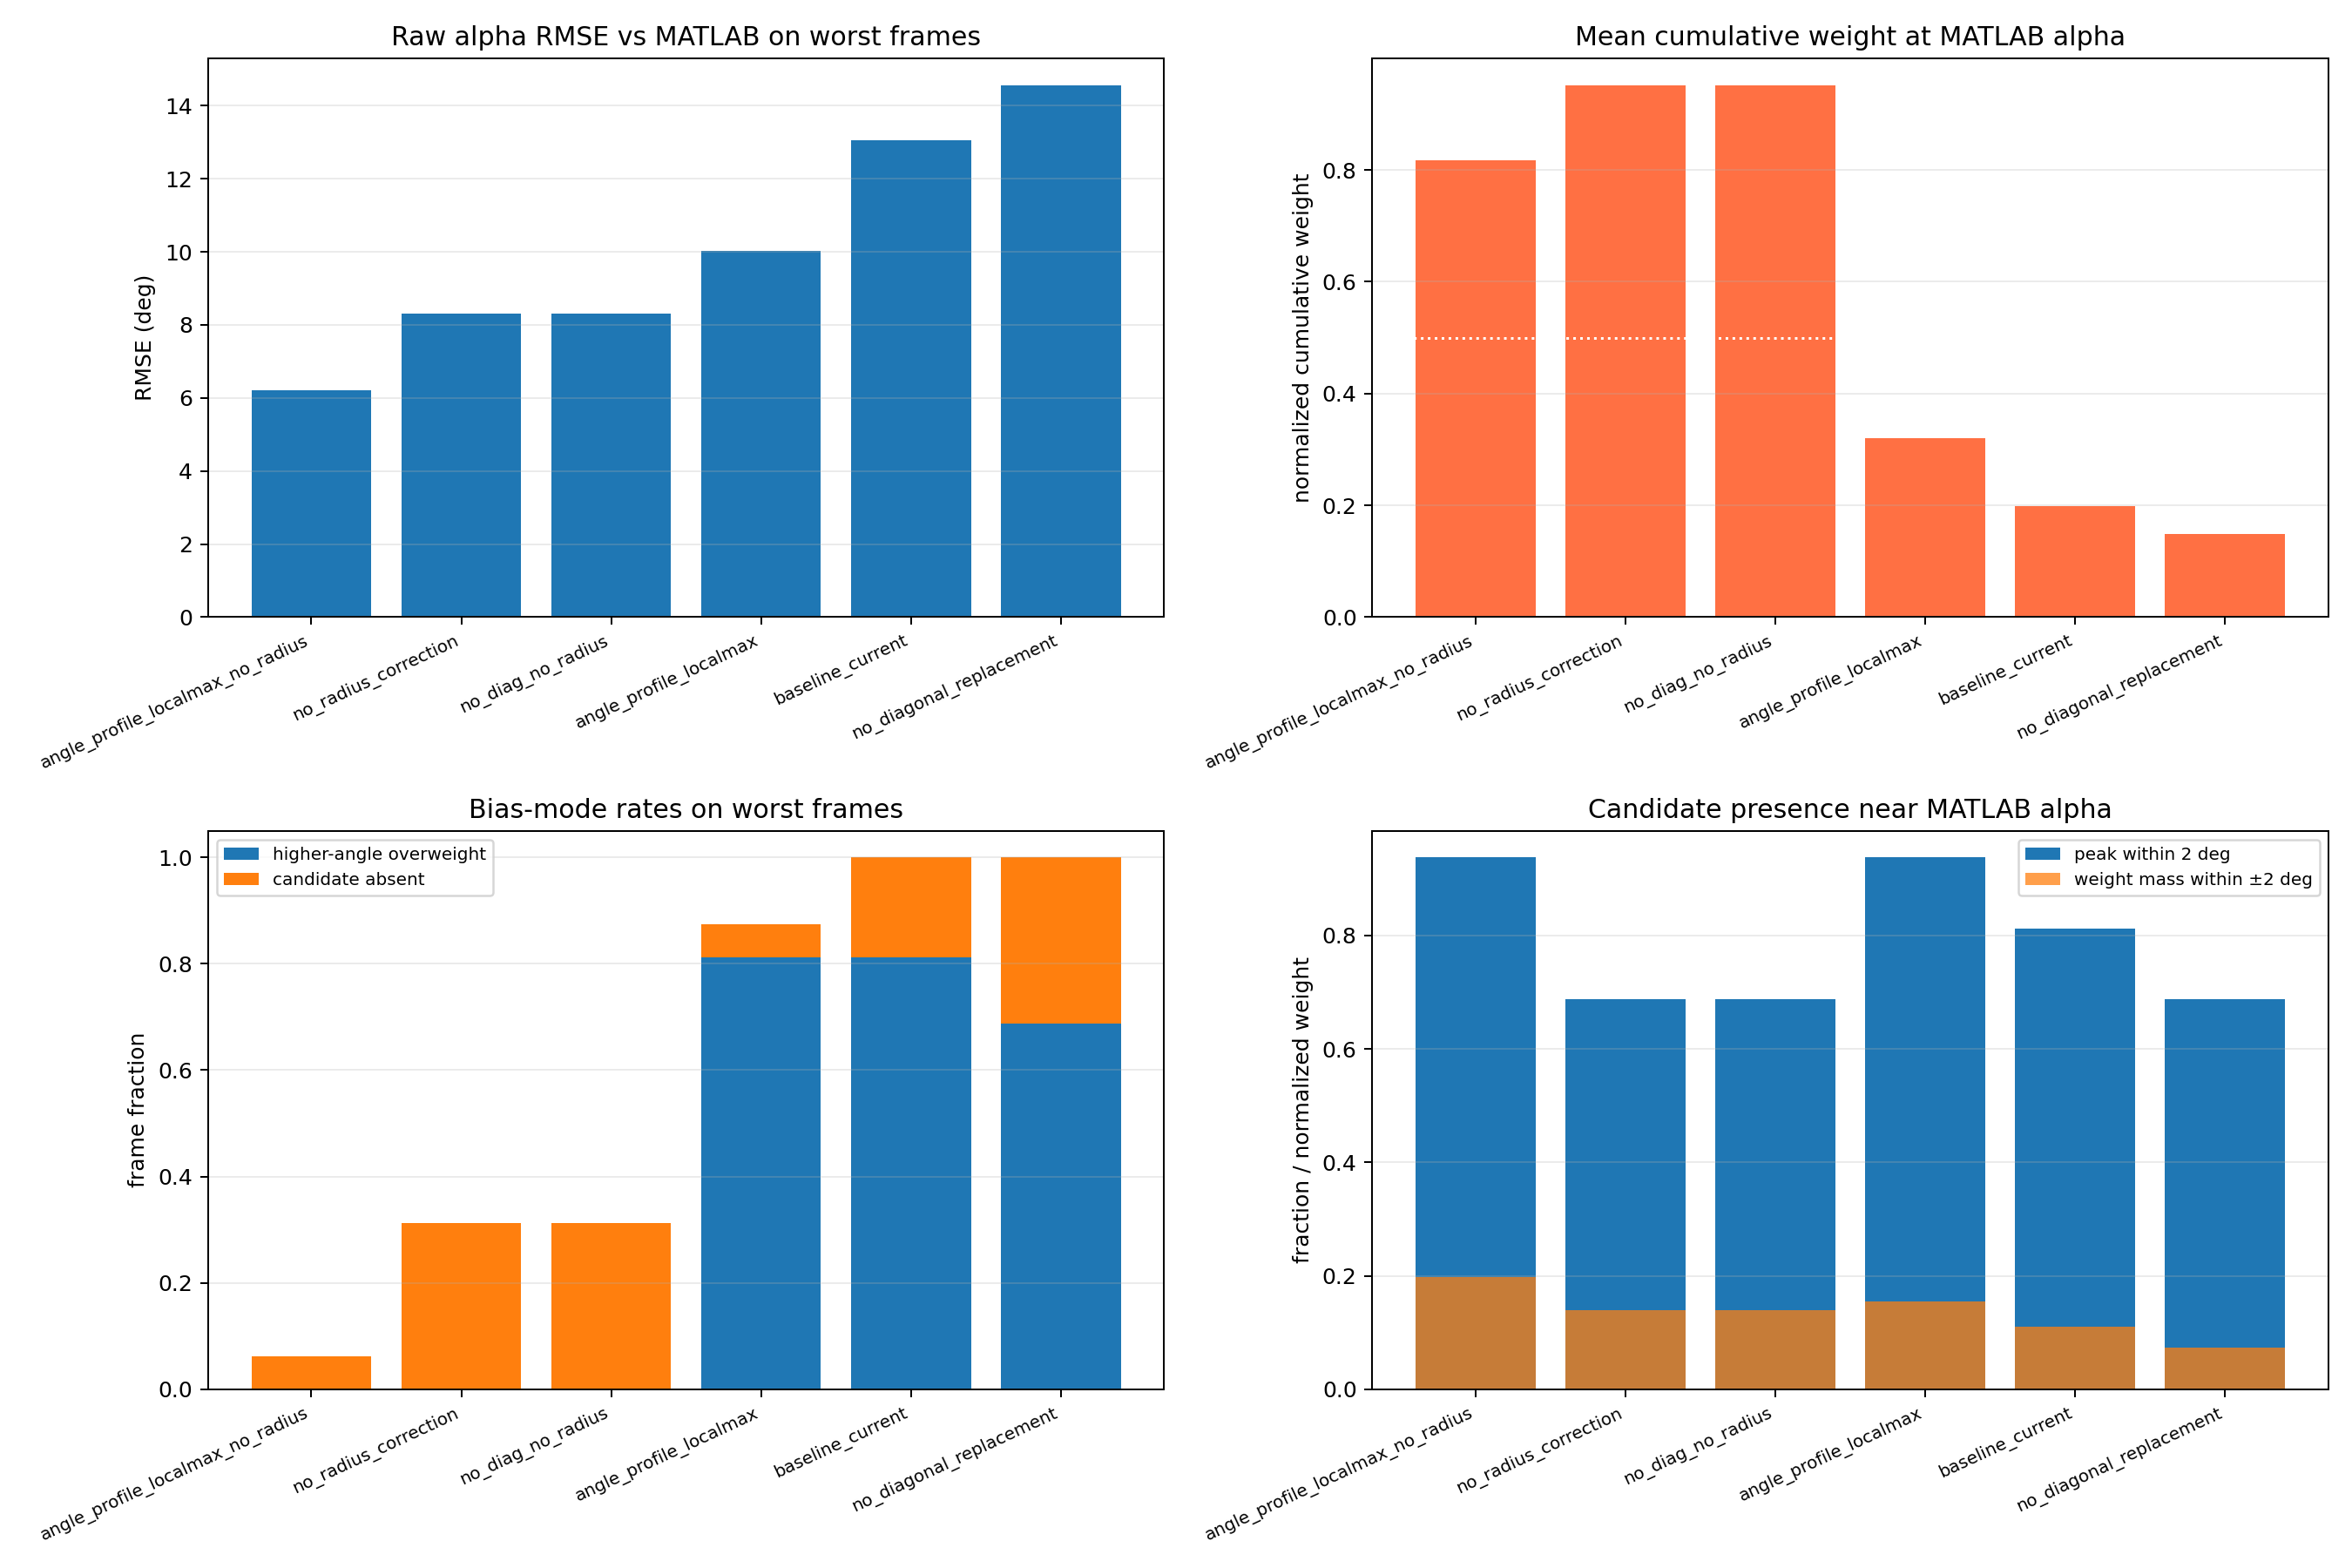

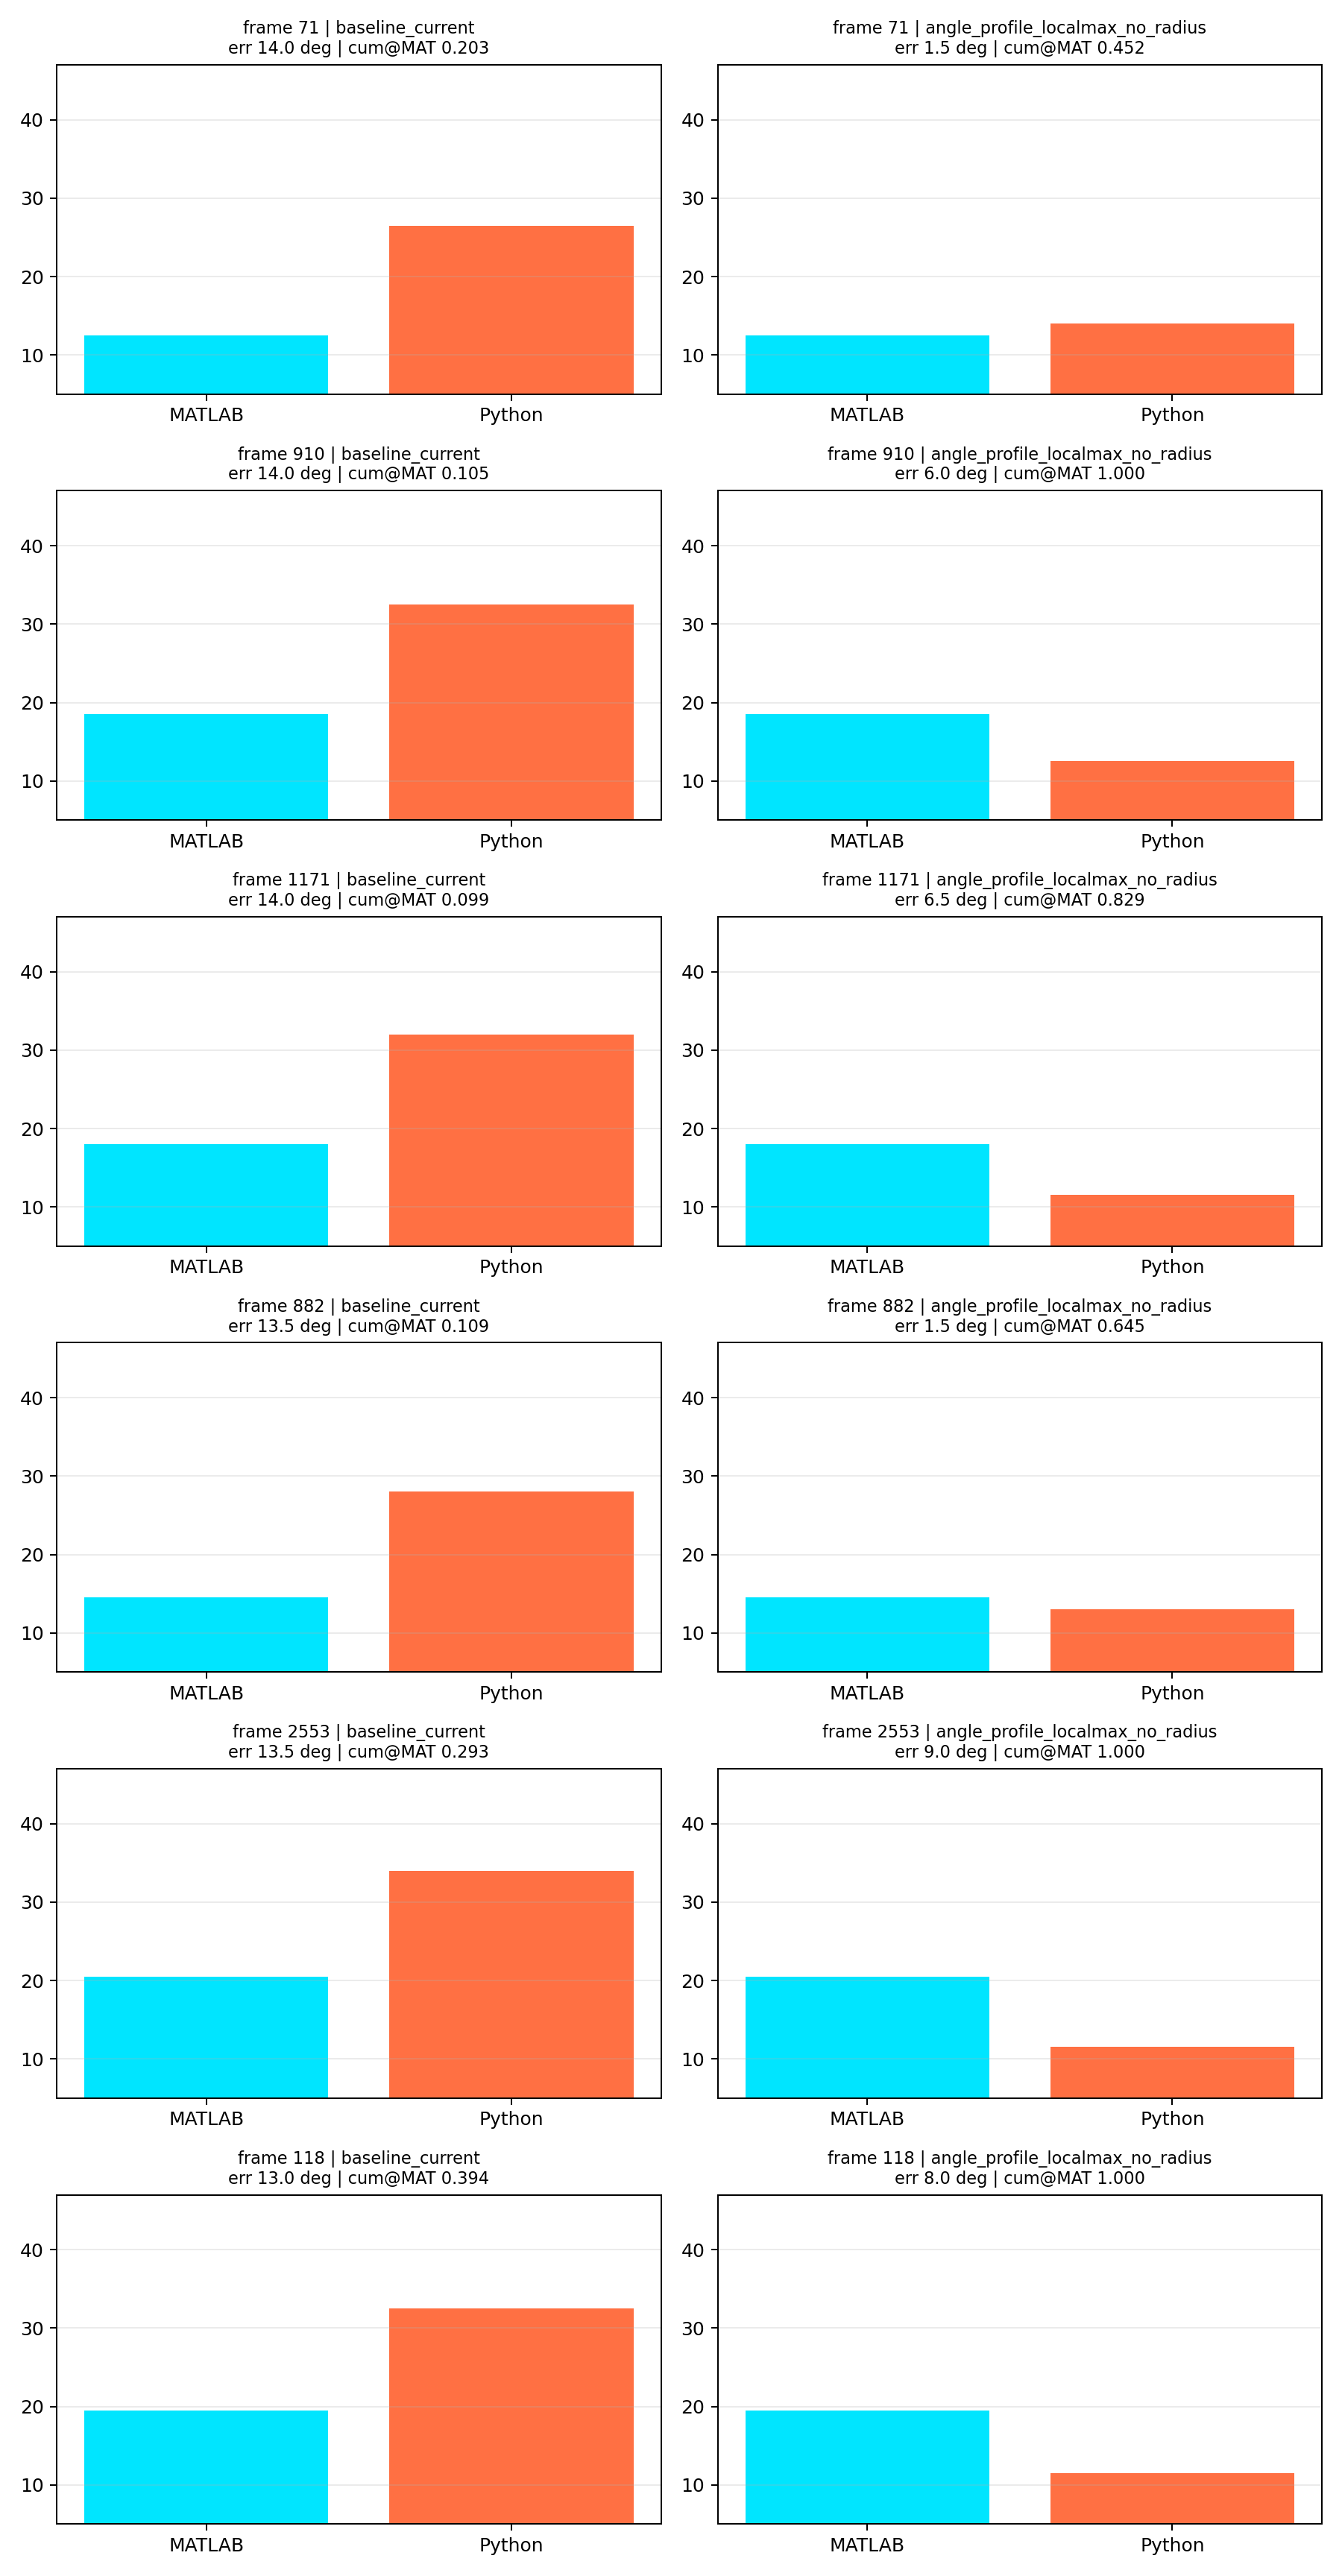

In [4]:
display(Image(filename=str(OUT / 'hough_knob_summary.png')))
display(Image(filename=str(OUT / 'hough_knob_exemplars.png')))